<a href="https://colab.research.google.com/github/RonGarcia-hub/CPE311-CPE22S3/blob/main/HOA_9_1_Garcia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##9.1 Introduction to Matplotlib

In [2]:
import matplotlib.pyplot as plt
import pandas as pd



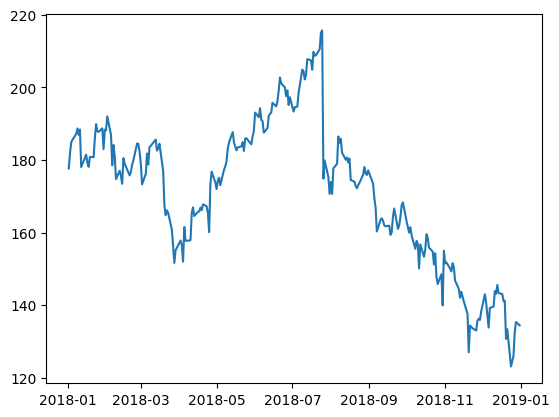

In [6]:
fb = pd.read_csv('fb_stock_prices_2018.csv', index_col='date', parse_dates=True)
plt.plot(fb.index, fb.open)
plt.show()


With the code above we were able to create a simple line plot with the x axis being assigned the date and the y axis being assigned the open price.


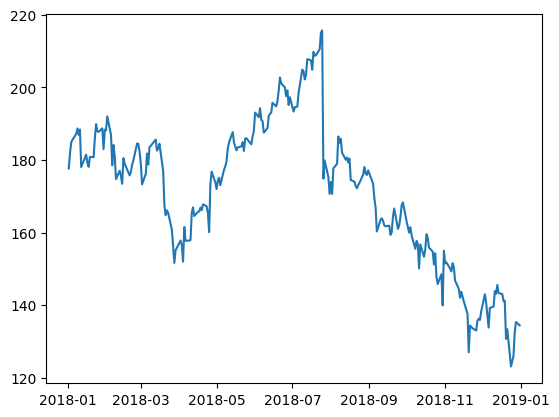

In [30]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
fb = pd.read_csv(
'fb_stock_prices_2018.csv', index_col='date', parse_dates=True
)
plt.plot(fb.index, fb.open)

This just makes it so that we don't have to input plt.show() for each code that we do.

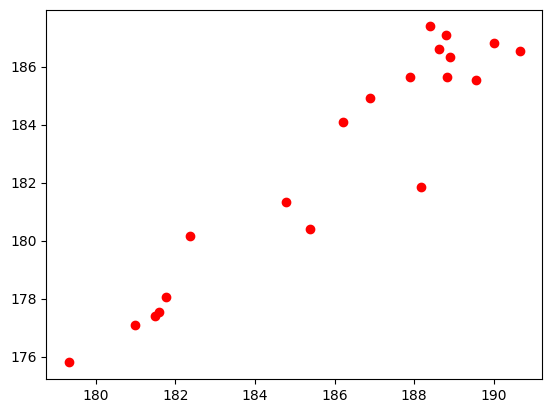

In [8]:
plt.plot('high', 'low', 'ro', data=fb.head(20))

This makes high(X-axis) and low(Y-axis) scatter plot with first 20 entry of the csv.

(array([6.400e+01, 4.450e+02, 1.137e+03, 1.853e+03, 2.114e+03, 8.070e+02,
        2.800e+02, 9.200e+01, 9.000e+00, 2.000e+00]),
 array([-1.26 , -0.624,  0.012,  0.648,  1.284,  1.92 ,  2.556,  3.192,
         3.828,  4.464,  5.1  ]),
 <BarContainer object of 10 artists>)

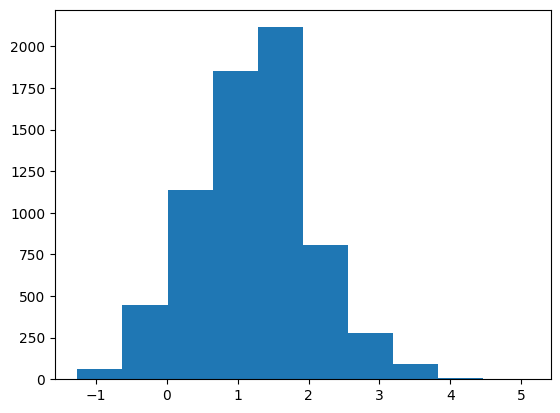

In [9]:
quakes = pd.read_csv('earthquakes-1.csv')
plt.hist(quakes.query('magType == "ml"').mag)

This makes a histogram of the earthquakes csv, this also makes it so that it only shows the entries that has the "ml" magType.

Text(0.5, 1.0, 'bins param: 35')

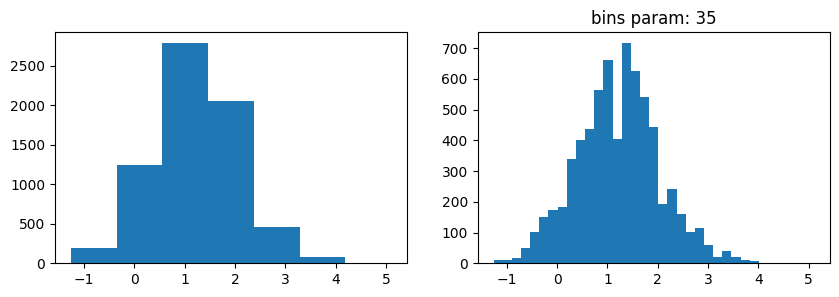

In [ ]:
x = quakes.query('magType == "ml"').mag
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, bins in zip(axes, [7, 35]):
   ax.hist(x, bins=bins)
ax.set_title(f'bins param: {bins}')

In the images above we were shown the difference in having different bin sizes. Bin size 7 shows a simplified form of the data having less groups while bin size 35 shows more group which makes it more crowded.

In [ ]:

fig = plt.figure()

<Figure size 640x480 with 0 Axes>

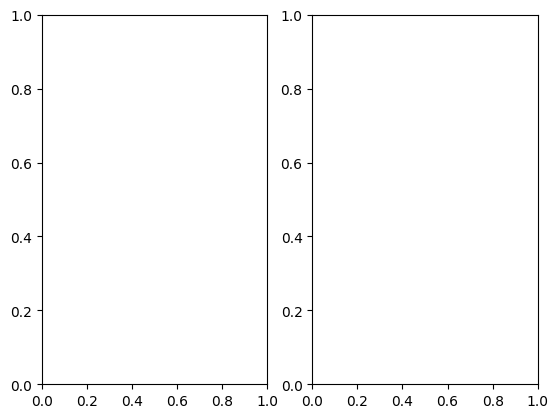

In [ ]:
fig, axes = plt.subplots(1, 2)

Subplot basically allows us to automatically create a grid layout

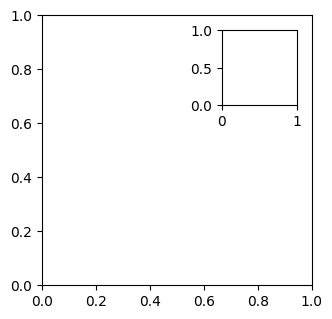

In [10]:
fig = plt.figure(figsize=(3, 3))
outside = fig.add_axes([0.1, 0.1, 0.9, 0.9])
inside = fig.add_axes([0.7, 0.7, 0.25, 0.25])

The code above shows us how ot manually create a layout without sublplot, assigning each values needed ourselves.

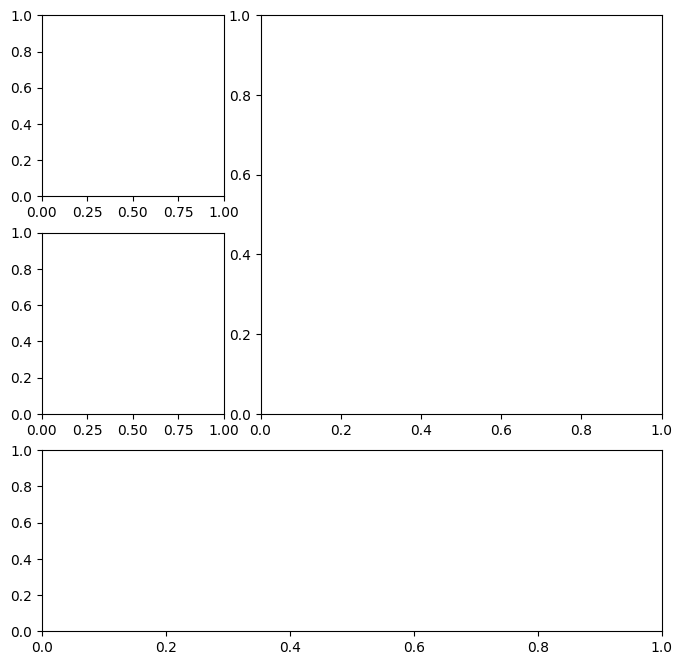

In [ ]:
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(3, 3)
top_left = fig.add_subplot(gs[0, 0])
mid_left = fig.add_subplot(gs[1, 0])
top_right = fig.add_subplot(gs[:2, 1:])
bottom = fig.add_subplot(gs[2,:])

This is a layout created using gridspec

##9.2 Plotting with Pandas

In [3]:
import numpy as np


<Axes: title={'center': 'Evolution of Facebook Open Price'}, xlabel='date'>

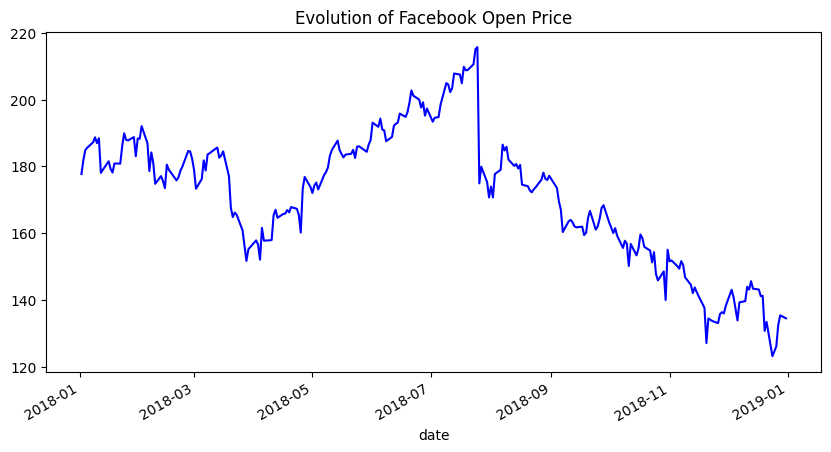

In [ ]:
fb.plot(
  kind='line',
  y='open',
  figsize=(10, 5),
  style='b-',
  legend=False,
  title='Evolution of Facebook Open Price'
)

This makes a line plot using pandas, with and addition of a title at the top

<Axes: title={'center': 'Evolution of Facebook Open Price'}, xlabel='date'>

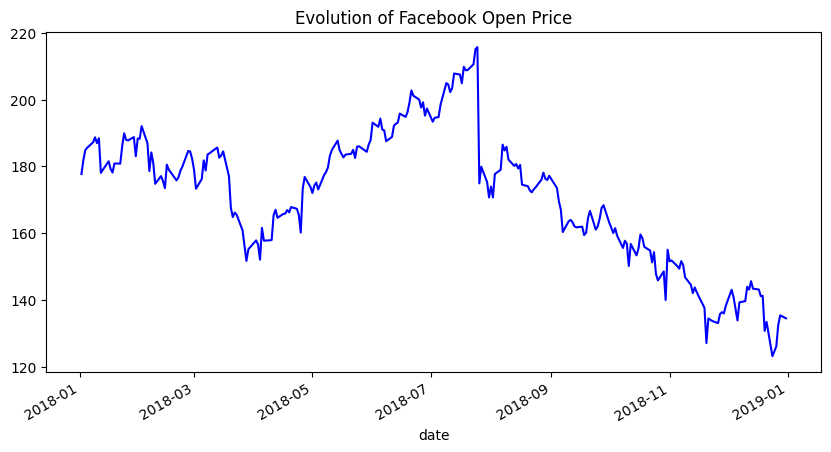

In [ ]:
fb.plot(
kind='line',
y='open',
figsize=(10, 5),
color='blue',
linestyle='solid',
legend=False,
title='Evolution of Facebook Open Price'
)

Same output as the previous one, with the difference in coding using linestyle and color.

<Axes: title={'center': 'Facebook OHLC Prices during 1st Week of Trading 2018'}, xlabel='date'>

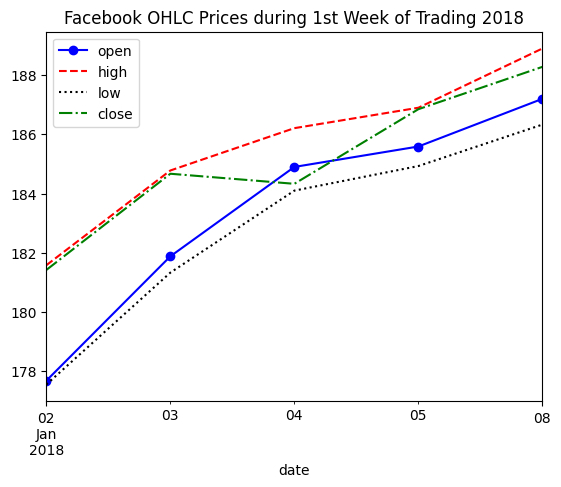

In [ ]:
fb.iloc[:5,].plot(
y=['open', 'high', 'low', 'close'],
style=['b-o', 'r--', 'k:', 'g-.'],
title='Facebook OHLC Prices during 1st Week of Trading 2018'
)

This shows the first five entry of the csv while plotting the data for open, high, low, and close

array([[<Axes: xlabel='date'>, <Axes: xlabel='date'>],
       [<Axes: xlabel='date'>, <Axes: xlabel='date'>],
       [<Axes: xlabel='date'>, <Axes: xlabel='date'>]], dtype=object)

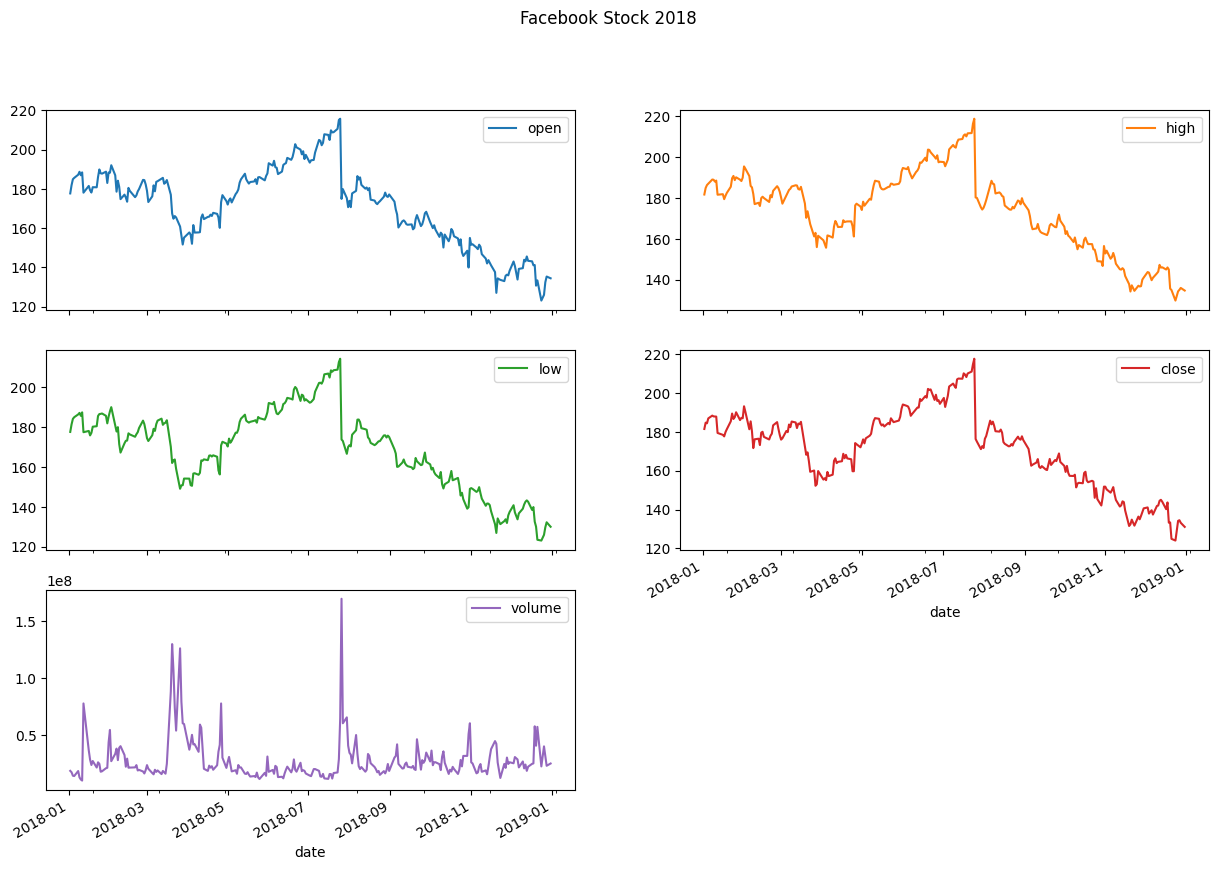

In [ ]:
fb.plot(
kind='line',
subplots=True,
layout=(3,2),
figsize=(15,10),
title='Facebook Stock 2018'
)

This shows different line chart for each column of data in the csv which makes it easier to see it individually

<Axes: title={'center': 'Facebook Daily High - Low vs. Volume Traded'}, xlabel='volume', ylabel='max_abs_change'>

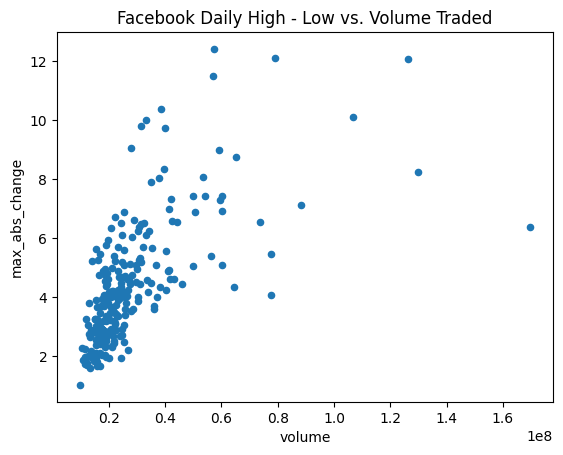

In [ ]:
fb.assign(
max_abs_change=fb.high - fb.low
).plot(
kind='scatter', x='volume', y='max_abs_change',
title='Facebook Daily High - Low vs. Volume Traded'
)

This makes a scatter plot to shows the change in prices by subtracting the high and low prices.

<Axes: title={'center': 'Facebook Daily High - Low vs. log(Volume Traded)'}, xlabel='volume', ylabel='max_abs_change'>

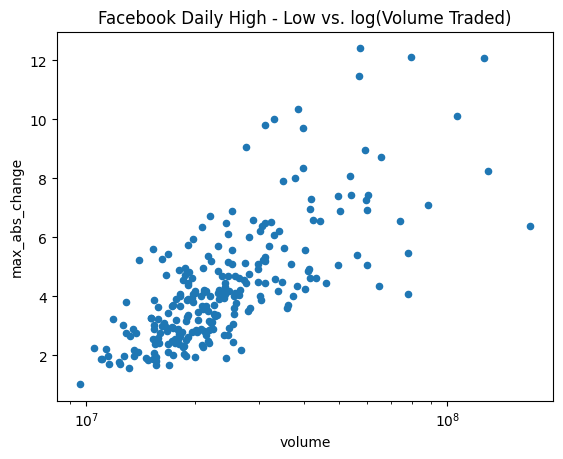

In [ ]:
fb.assign(
max_abs_change=fb.high - fb.low
).plot(
kind='scatter', x='volume', y='max_abs_change',
title='Facebook Daily High - Low vs. log(Volume Traded)',
logx=True)

Volume is displayed on a logarthmic scale

<Axes: title={'center': 'Facebook Daily High - Low vs. log(Volume Traded)'}, xlabel='volume', ylabel='max_abs_change'>

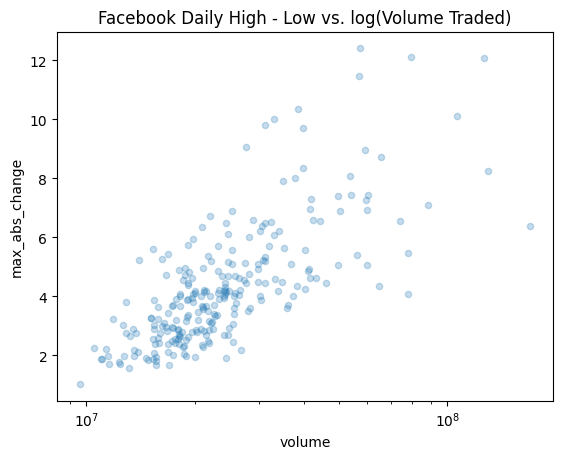

In [11]:
fb.assign(
max_abs_change=fb.high - fb.low
).plot(
kind='scatter', x='volume', y='max_abs_change',
title='Facebook Daily High - Low vs. log(Volume Traded)',
logx=True, alpha=0.25)

Alpha function gives different transparency values on the scatter plot.

<Axes: title={'center': 'Facebook Daily High - Low vs. log(Volume Traded)'}, xlabel='log_volume', ylabel='max_abs_change'>

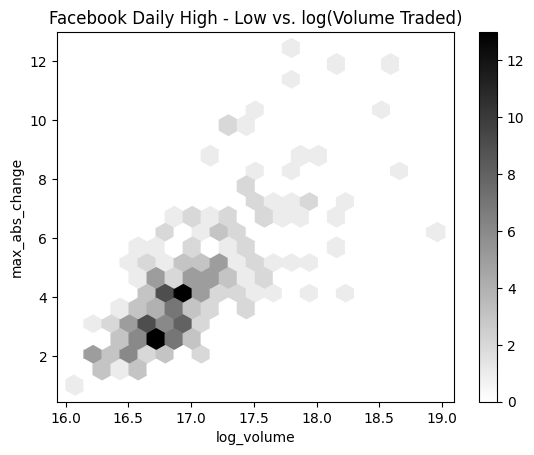

In [12]:
fb.assign(
log_volume=np.log(fb.volume),
max_abs_change=fb.high - fb.low
).plot(
kind='hexbin',
x='log_volume',
y='max_abs_change',
title='Facebook Daily High - Low vs. log(Volume Traded)',
colormap='gray_r',
gridsize=20,
sharex=False)

Creates a greyscale hexplot.

AttributeError: 'Colorbar' object has no attribute 'set_clim'

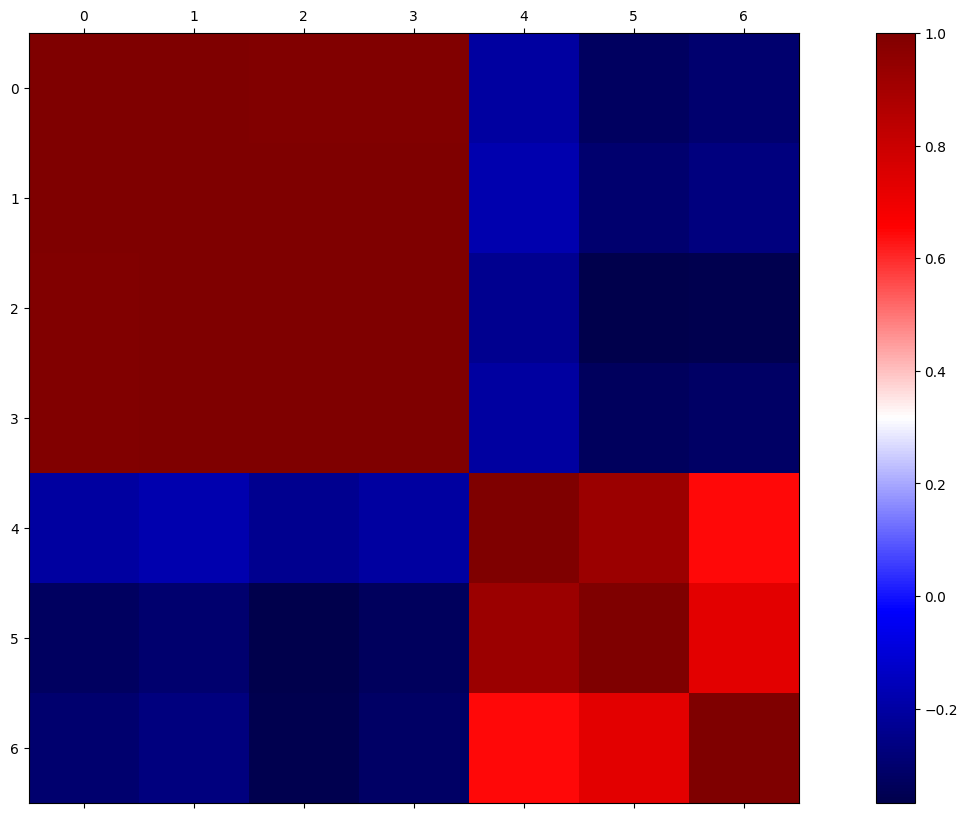

In [13]:
fig, ax = plt.subplots(figsize=(20, 10))
fb_corr = fb.assign(
log_volume=np.log(fb.volume),
max_abs_change=fb.high - fb.low
).corr()
im = ax.matshow(fb_corr, cmap='seismic')
fig.colorbar(im).set_clim(-1, 1)
labels = [col.lower() for col in fb_corr.columns]
ax.set_xticklabels([''] + labels, rotation=45)
ax.set_yticklabels([''] + labels)

This makes a heatmap depending on the correlation of each variable.

Text(0.5, 0, 'Volume traded')

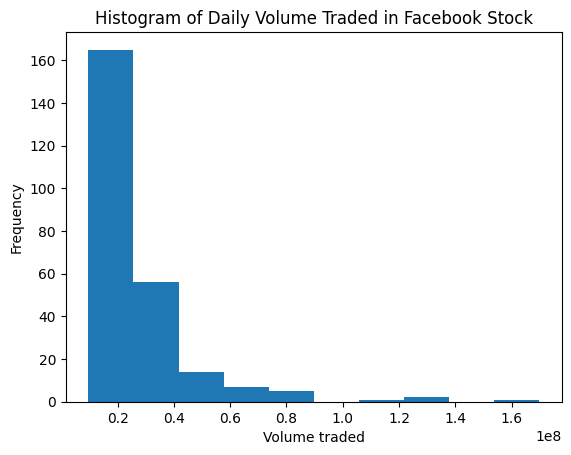

In [14]:
fb.volume.plot(
kind='hist',
title='Histogram of Daily Volume Traded in Facebook Stock'
)
plt.xlabel('Volume traded')

This makes a histogram of the frequency of volume traded regarding fb stock.


Text(0.5, 0, 'magnitude')

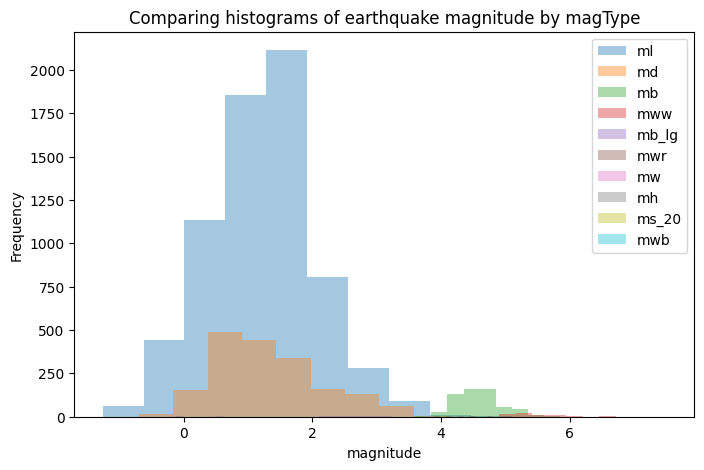

In [18]:
fig, axes = plt.subplots(figsize=(8, 5))
for magtype in quakes.magType.unique():
  data = quakes.query(f'magType == "{magtype}"').mag
  if not data.empty:
    data.plot(
kind='hist', ax=axes, alpha=0.4,
label=magtype, legend=True,
title='Comparing histograms of earthquake magnitude by magType'
)
plt.xlabel('magnitude')

This creates a easy to compare visualization of different histograms.

Text(0.5, 0, 'Price ($)')

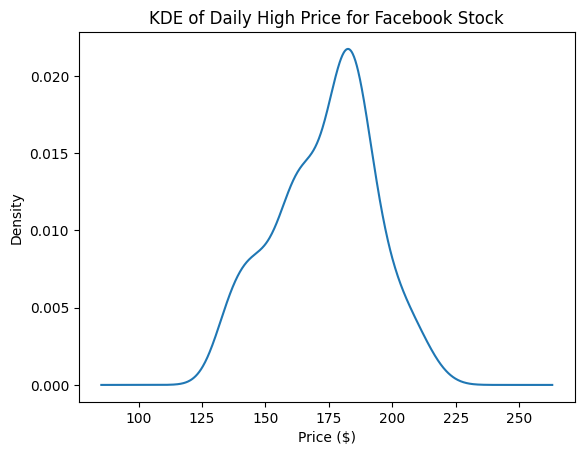

In [19]:
fb.high.plot(
kind='kde',
title='KDE of Daily High Price for Facebook Stock'
)
plt.xlabel('Price ($)')

This makes a kernel density estimate, looks smoother compared to a line plot.

##Supplementary Activity

<Axes: title={'center': 'Facebook 20-Day Rolling Minimum Closing Price'}, xlabel='date'>

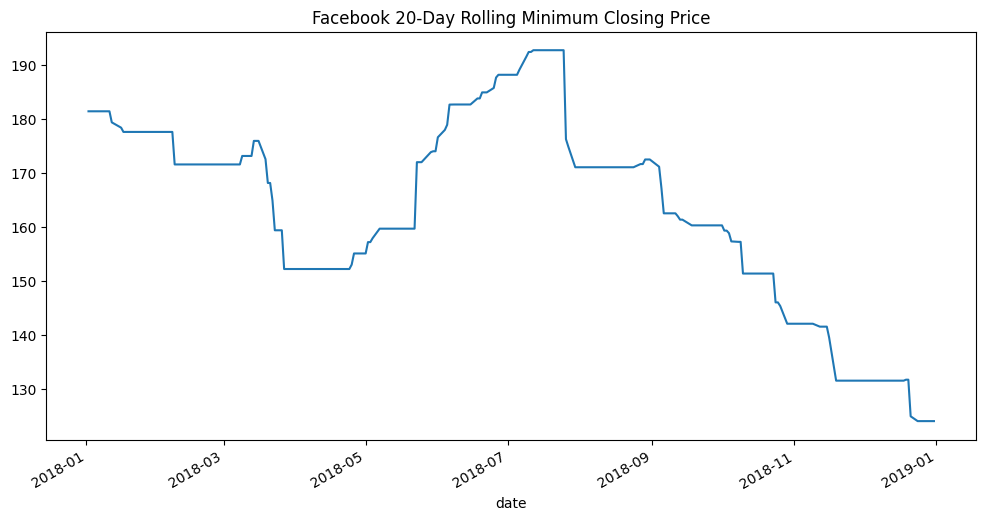

In [20]:
# 1.Plot the rolling 20-day minimum of the Facebook closing price with the pandas plot() method.

fb['close'].rolling(window=20, min_periods=1).min().plot(
    title='Facebook 20-Day Rolling Minimum Closing Price',
    figsize=(12,6)
)

Text(0, 0.5, 'Density')

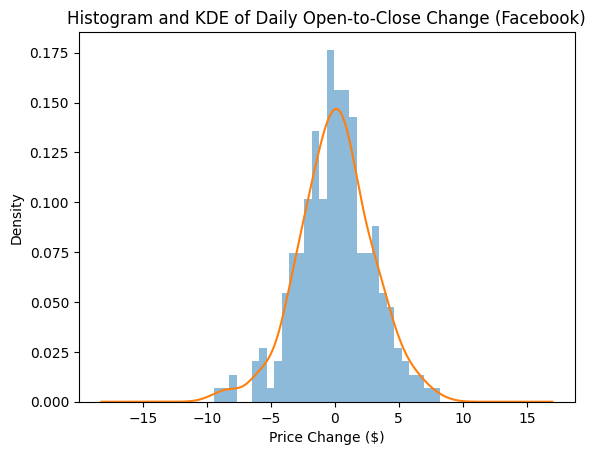

In [21]:
# 2. Create a histogram and KDE of the change from open to close in the price of Facebook stock.

price_change = fb['close'] - fb['open']

price_change.plot(
    kind='hist',
    bins=30,
    density=True,
    alpha=0.5,
    title='Histogram and KDE of Daily Open-to-Close Change (Facebook)'
)

price_change.plot(kind='kde')

plt.xlabel('Price Change ($)')
plt.ylabel('Density')

Text(0, 0.5, 'Magnitude')

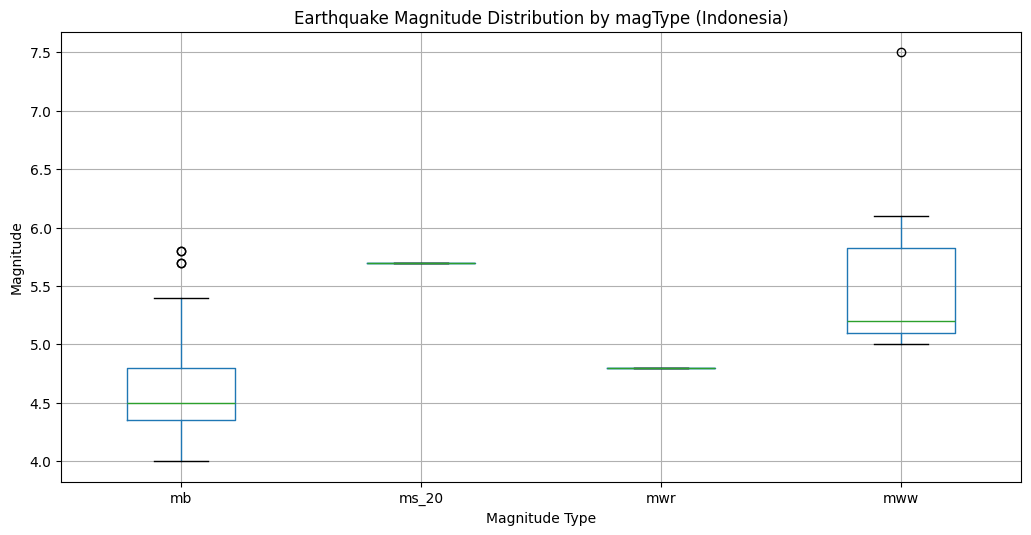

In [23]:
# 3. Using the earthquake data, create box plots for the magnitudes of each magType used in Indonesia.

quakes[quakes['place'].str.contains('Indonesia', na=False)] \
    .dropna(subset=['mag', 'magType']) \
    .boxplot(column='mag', by='magType', figsize=(12,6))

plt.title('Earthquake Magnitude Distribution by magType (Indonesia)')
plt.suptitle('')
plt.xlabel('Magnitude Type')
plt.ylabel('Magnitude')

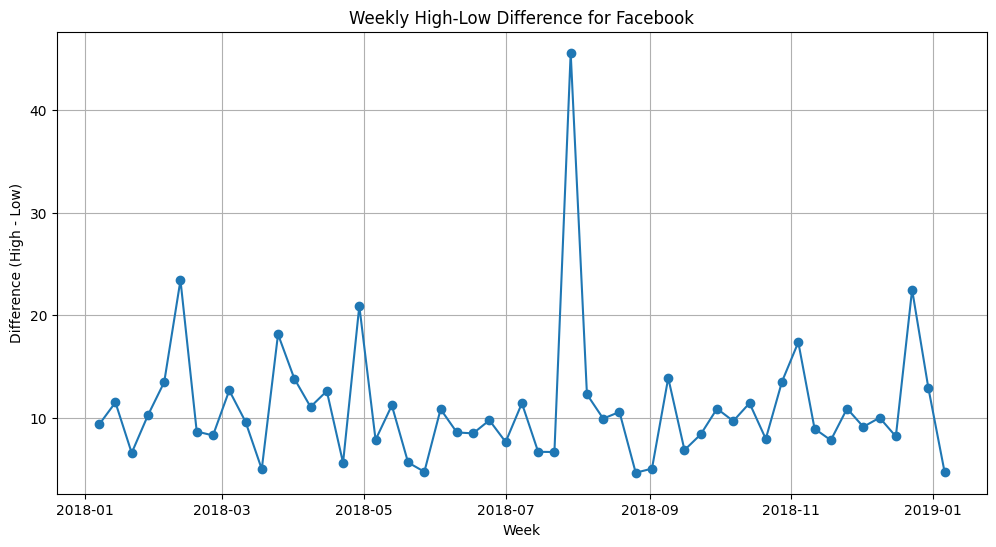

In [29]:
# 4. Make a line plot of the difference between the weekly maximum high price and the weekly minimum low price for Facebook. This should be a single line.


fb['date'] = pd.to_datetime(fb['date'])

fb.set_index('date', inplace=True)

weekly_high = fb['high'].resample('W').max()
weekly_low = fb['low'].resample('W').min()

weekly_diff = weekly_high - weekly_low

plt.figure(figsize=(12,6))
plt.plot(weekly_diff, marker='o', linestyle='-')
plt.title('Weekly High-Low Difference for Facebook')
plt.xlabel('Week')
plt.ylabel('Difference (High - Low)')
plt.grid(True)
plt.show()


/tmp/ipykernel_455/2436866629.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_net = after_hours.resample('M').sum()


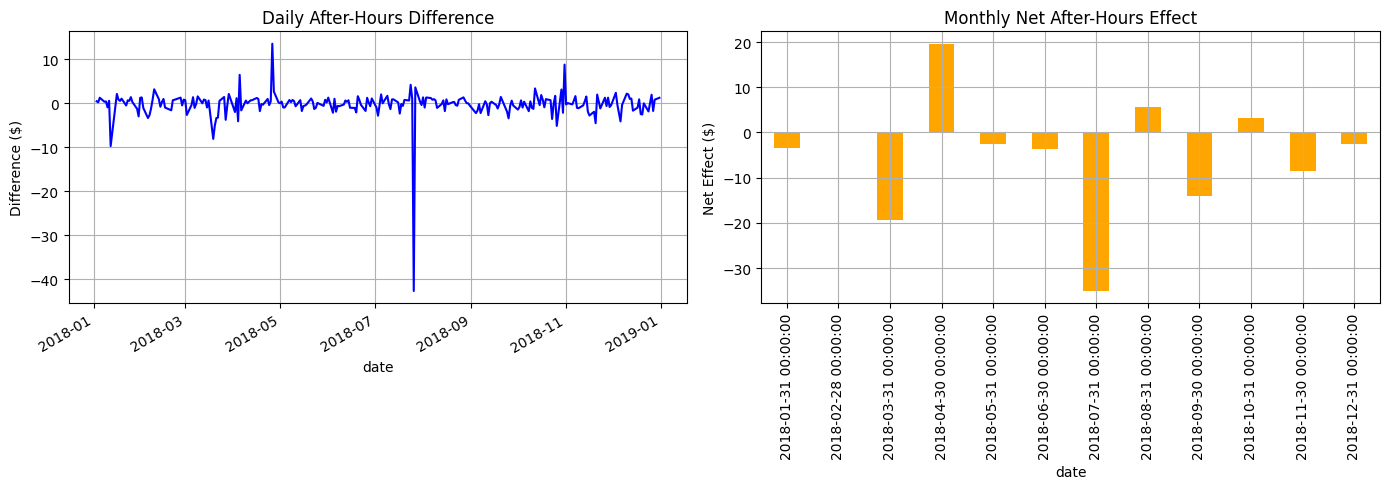

In [35]:
#Using matplotlib and pandas, create two subplots side-by-side showing the effect that after-hours trading has had on Facebook's stock price:
#The first subplot will contain a line plot of the daily difference between that day's opening price and the prior day's closing price (be sure to review the Time series section of Aggregating Pandas DataFrames for an easy way to do this).
#The second subplot will be a bar plot showing the net effect this had monthly, using resample().

fb['date'] = pd.to_datetime(fb['date'])
fb.set_index('date', inplace=True)

after_hours = fb['open'] - fb['close'].shift(1)

monthly_net = after_hours.resample('M').sum()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

after_hours.plot(ax=axes[0], color='blue', title="Daily After-Hours Difference")
axes[0].set_ylabel("Difference ($)")
axes[0].grid(True)

monthly_net.plot(kind='bar', ax=axes[1], color='orange', title="Monthly Net After-Hours Effect")
axes[1].set_ylabel("Net Effect ($)")
axes[1].grid(True)

plt.tight_layout()